In [1]:
#!pip install camb

In [2]:
# Main dependencies
import scipy.fftpack
from scipy.interpolate import CubicSpline
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os
import camb
from camb import model, initialpower
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datetime import date
from datetime import datetime
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

print(torch.cuda.device_count())
# prints number of GPUs available

Using CAMB 1.6.5 installed at /global/homes/a/ajtorres/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/camb
4


In [3]:
field_size = 32
fields_num = 1000
model_num = 2
h = 0.7

In [4]:
def fftind(size):
    """ Returns a numpy array of shifted Fourier coordinates k_x k_y k_z.
        
        Input args:
            size (integer): The size of the coordinate array to create
        Returns:
            k_ind, numpy array of shape (3, size, size, size) with:
                k_ind[0,:,:,:]:  k_x components
                k_ind[1,:,:,:]:  k_y components
                k_ind[2,:,:,:]:  k_z components
            
        """
    #Below, I have added an extra ':size' to the make the output 3D
    k_ind = np.mgrid[:size, :size, :size] - int( (size + 1)/2 )
    k_ind = scipy.fftpack.fftshift(k_ind) / (1000*h) * 2*np.pi
    return( k_ind )

In [5]:
# Set cosmological parameters
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)

# Get matter power spectra at redshift 0
pars.set_matter_power(redshifts=[0.0], kmax=2.0)

# Non-Linear spectra (Halofit)
results = camb.get_results(pars)
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)

# In order to get a reasonable number of galaxies (~10^6), I need my minimum k to be 0.001
# Maximum k should then be the number of boxels along one side of the field times the minimum
# k. My fields won't be able to resolve the effects of larger k.

mink = 2*np.pi*0.001 / (2*h)# Divided by 2 to account for maximum squashing
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh= mink, maxkh= field_size * mink * 4, npoints= 10000)
# Multiplied by 4 to account for previous division by 2 and the maximum stretching

In [6]:
stretch = np.random.uniform(1 / 1.5, 1.5)
print(stretch)

0.9779557160072394


In [7]:
def stretched_power(max_stretch, field_size):
    stretch = np.random.uniform(1 / max_stretch, max_stretch)
    
    # For each position in k-space, I want to calculate the separation from the origin
    k_idx = fftind(field_size)
    
    # We stretch physical space along one or more of the axes by a factor of the stretch
    # Stretch factor multiplied by k_idx[0] stretches the images horizontally
    # Stretch factor multiplied by k_idx[2] stretches the images vertically
    k_sep = np.sqrt((k_idx[0] * stretch)**2 + (k_idx[1])**2 + (k_idx[2])**2)
    
    # Because we have not defined the power spectrum for every k we want to evaluate, we interpolate
    power_interpolator = CubicSpline(kh_nonlin, pk_nonlin[0], extrapolate = False)
    amplitude = power_interpolator(k_sep)
    amplitude[0][0][0] = 0
    
    return amplitude, stretch

In [8]:
def gaussian_random_field(size = field_size, flag_normalize = True):
    """
        Input args:
            size (integer):
                The size of the square output Gaussian Random Fields
            flag_normalize (boolean, default = True):
                Normalizes the Gaussian Field:
                    - to have an average of 0.0
                    - to have a standard deviation of 1.0

        Returns:
            gfield (numpy array of shape (size, size, size)):
                The random gaussian random field
                
        Example:
        import matplotlib.pyplot as plt
        example = gaussian_random_field()
        plt.imshow(example)
        """
 
        # Draws a complex gaussian random noise with normal (circular) distribution
    noise = np.random.normal(size = (size, size, size)) \
        + 1j * np.random.normal(size = (size, size, size))

    power, stretch = stretched_power(max_stretch = 1.05, field_size = size)
    amplitude = np.sqrt(power)
    
        # To real space
    gfield = np.fft.ifftn(noise * amplitude).real
    
        # Sets the standard deviation to one
    if flag_normalize:
        gfield = gfield - np.mean(gfield)
        gfield = gfield/np.std(gfield)
        
    return gfield, stretch

In [9]:
'''
def Gaussian_to_Galaxy_Field(N_gal):
    Gaussian_field, stretch = gaussian_random_field() #This gets us a 3D array with values representing a Gaussian random field with variance 1
    density_field_weights = np.exp(Gaussian_field - 1/2) #Takes Gaussian field and converts it to a realistic density field weighting
    sum_weights = np.sum(density_field_weights)
    galaxy_probs = density_field_weights / sum_weights
    
    # This uses the density field weighting and populates an array representing the actual distribution of galaxies in 3D space
    galaxy_probs_flat = galaxy_probs.flatten()
    N_gal_dist_flat = np.random.multinomial(N_gal, galaxy_probs_flat)
    N_gal_dist = N_gal_dist_flat.reshape((field_size, field_size, field_size))
    return N_gal_dist, Gaussian_field, stretch
''';

In [10]:
'''
# This is to figure out how many galaxies I would have in a box for each tracer
k_min = 1/1000 # Mpc^-1
box_volume = k_min ** -3 # Mpc^3
vol_tracer = 10**9 #Mpc^3
N_gal_tracer = 10**6

N_gal = round(N_gal_tracer / vol_tracer * box_volume) # multiply measured galaxy density by volume of my box
print(N_gal)
''';

In [11]:

#Here we make the training data with each individual image stretched by a different random amount, but that stretch factor can be relatively large
# Numpy array to store labels
labels = torch.zeros(fields_num)

# Numpy array to store field data
Gauss_fields = torch.zeros([fields_num, 1, field_size, field_size, field_size])

for num in range(fields_num):
    #return 3D array with values representing a galaxy field
    Gauss_field, stretch = gaussian_random_field()
        
    # Convert into a tensor
    #Gal_field_tensor = torch.tensor(Gal_field_normal, dtype=torch.float)
    Gauss_field_tensor = torch.tensor(Gauss_field, dtype=torch.float)
    #Gal_fields[num][0] = Gal_field_tensor
    Gauss_fields[num][0] = Gauss_field_tensor
    labels[num] = stretch

In [12]:
#This class is meant to take arrays of pixel values and labels and prepare them in a state that the dataloader 
#can process and then give to the neural network
class CustomThrimageDataset():
    def __init__(self, labels, data, transforms = False):
        self.labels = labels
        self.data = data
        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        thrimage = self.data[idx]
        label = self.labels[idx]
        clonethrimage = thrimage.clone()
        if self.transforms:
            clonethrimage = self.transforms(clonethrimage)
        return clonethrimage, label

In [13]:
if model_num == 1:
    # Original, very simple network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv1 = nn.Conv3d(1, 6, 5, padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
            self.conv2 = nn.Conv3d(6, 16, 5,  padding = 2)
    
        
            self.fc1 = nn.Linear(int(16 * field_size/(2**2) * field_size/(2**2) * field_size/(2**2)) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
    
            x = torch.flatten(x, 1)
            
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 2:
    #This is a slightly deeper convolutional network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            self.conv13 = nn.Conv3d(16, 16, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(16 * (field_size/(2**2))**3) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = self.pool(F.relu(self.conv13(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 3:
    #This is an even deeper convolutional network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            
            self.conv21 = nn.Conv3d(16, 32, 5,  padding = 2)
            self.conv22 = nn.Conv3d(32, 32, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(32 * (field_size/(2**2))**3) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = F.relu(self.conv21(x))
            x = self.pool(F.relu(self.conv22(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 4:
    #This is the same depth as the previous architecture with a slightly wider fully connected head
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            
            self.conv21 = nn.Conv3d(16, 32, 5,  padding = 2)
            self.conv22 = nn.Conv3d(32, 32, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(32 * (field_size/(2**2))**3) , 2000)
            self.fc2 = nn.Linear(2000, 400)
            self.fc3 = nn.Linear(400, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = F.relu(self.conv21(x))
            x = self.pool(F.relu(self.conv22(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

net = nn.DataParallel(Net())

device = torch.device("cuda:0")

In [14]:
criterion = nn.MSELoss()
lr = 0.001
optimizer = optim.SGD(net.parameters(), lr = lr, momentum = 0.9)

In [15]:
model_path = f'nnet_gauss_2026-04-08.pth'
net.load_state_dict(torch.load(model_path, weights_only=False))
net.eval()
net.to(device);

In [16]:
#Here we actually define the training and testing datasets in a way that the dataloader can process
testing_thrimages = CustomThrimageDataset(labels, Gauss_fields)

#Here we tell the dataloader what datasets we are giving it, how many images we want for each batch of training and whether we want the datasets
#to be shuffled between "rounds" of training
test_dataloader = DataLoader(testing_thrimages, batch_size=fields_num, shuffle=True)

In [17]:
test_loss = 0
for j, data in enumerate(test_dataloader):
    #inputs is a list of all the images in the batch and labels is a list of all the stretch factors in the batch
    inputs = data[0].to(device)
    labels = data[1].to(device)

    #Here we convert the image tensors into the float32 tensor type
    inputs = inputs.float()
    #Here we actually run the images through the network and get the network's guess for the stretch factor for each image in the batch
    outputs = net(inputs)
    #Here we "squeeze" out any single value arrays. Basically get rid of unneeded brackets
    outputs = outputs.squeeze()
    # Ensure the output is a float32 value
    outputs = outputs.float()
    # Ensure the labels are float32 (if they aren't already)
    labels = labels.float()
    #Here we compute the loss, just the square of the difference between the actual stretch factor and what the network guesses
    loss = criterion(outputs, labels)
    test_loss = loss.item()
    #print(outputs)
    error = np.sqrt(loss.item())
    print(f"The error is {error:.5f}")

The error is 0.02303


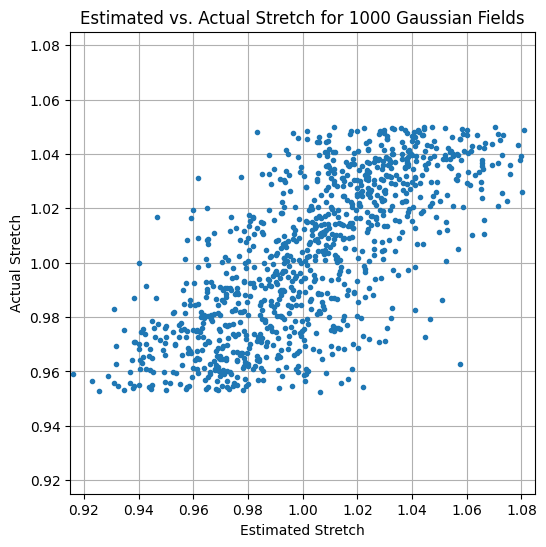

In [19]:
outputs = outputs.detach()
outputs = outputs.cpu()
labels = labels.cpu()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(outputs, labels, marker = '.', zorder = 2.5)
ax.set_title("Estimated vs. Actual Stretch for 1000 Gaussian Fields") 
ax.set_xlabel("Estimated Stretch")
ax.set_ylabel("Actual Stretch")
plt.xlim(0.915, 1.085)
plt.ylim(0.915, 1.085)
ax.grid()

plt.savefig("Gauss_Estimated_vs_Actual_Stretch_Smaller.pdf")